# Setup

In [ ]:
import os, sys
from pathlib import Path

PROJECT = Path.home() / "Desktop" / "Project" / "sales-forecasting-assistant"
os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT))
(PROJECT / "docs" / "images").mkdir(parents=True, exist_ok=True)
(PROJECT / "src" / "features").mkdir(parents=True, exist_ok=True)
print("Working in:", os.getcwd())

# Install Spark (one time only)

### When it finishes, go to Kernel → Restart, then run Cell 1 again.

In [ ]:
   %pip install "pyspark==3.5.*"

# Pull the weekly data from Snowflake

In [ ]:
import pandas as pd
from src.ingest.load_raw import get_connection

conn = get_connection()
cur = conn.cursor()
cur.execute("SELECT * FROM SALES_DB.STAGING.SALES_WEEKLY")
pdf = cur.fetch_pandas_all()
conn.close()

pdf["WEEK_START"] = pd.to_datetime(pdf["WEEK_START"])

# Drop the first and last week: they are partial weeks and would look like sales drops
pdf = pdf[(pdf["WEEK_START"] > pdf["WEEK_START"].min()) &
          (pdf["WEEK_START"] < pdf["WEEK_START"].max())]

print(pdf.shape)
pdf.head()

# These are the exploratory charts

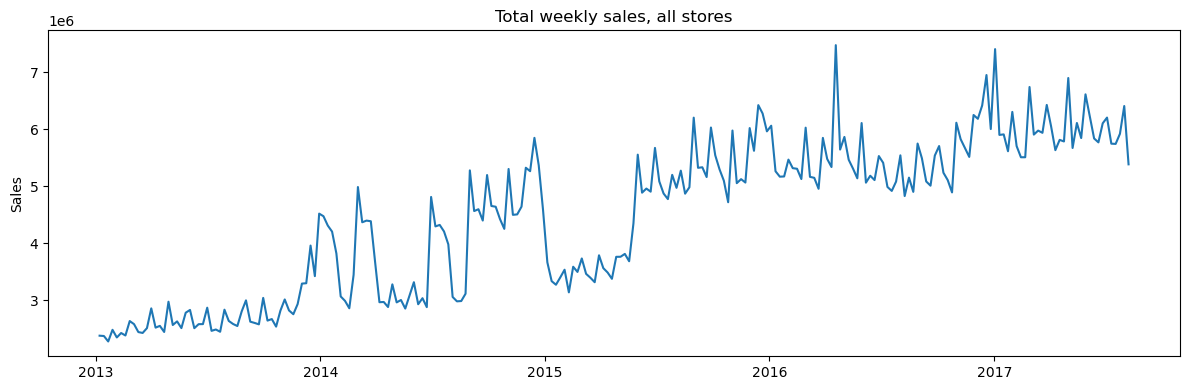

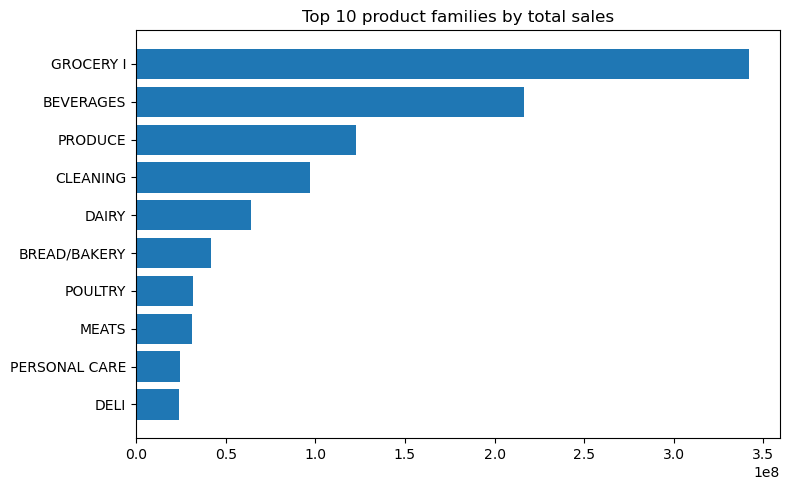

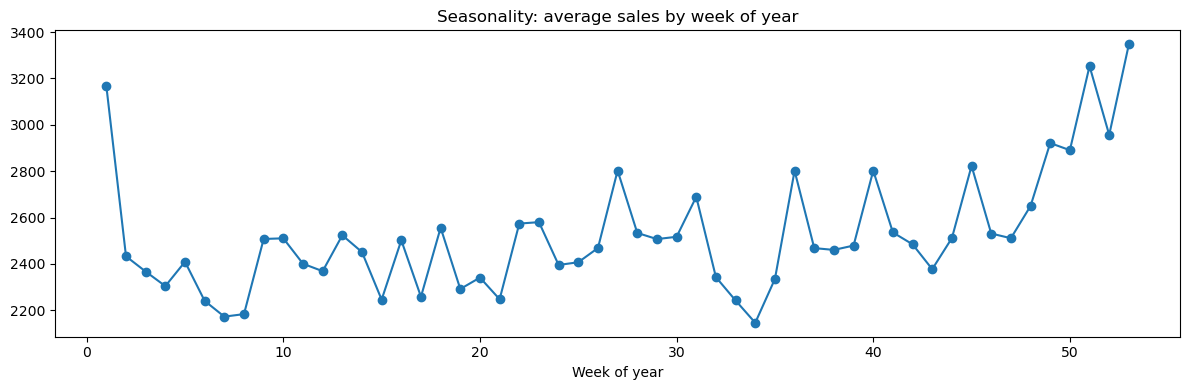

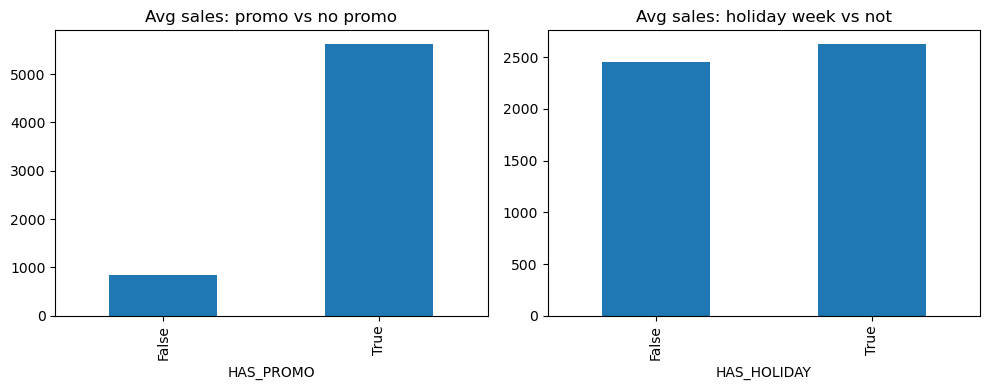

In [11]:
import matplotlib.pyplot as plt

IMG = "docs/images"

# 1. Total weekly sales over time
weekly = pdf.groupby("WEEK_START")["SALES"].sum()
plt.figure(figsize=(12, 4))
plt.plot(weekly.index, weekly.values)
plt.title("Total weekly sales, all stores"); plt.ylabel("Sales")
plt.tight_layout(); plt.savefig(f"{IMG}/01_weekly_sales.png"); plt.show()

# 2. Top 10 product families
top = pdf.groupby("FAMILY")["SALES"].sum().nlargest(10).sort_values()
plt.figure(figsize=(8, 5))
plt.barh(top.index, top.values)
plt.title("Top 10 product families by total sales")
plt.tight_layout(); plt.savefig(f"{IMG}/02_top_families.png"); plt.show()

# 3. Seasonality: average sales by week of the year
pdf["WEEK_OF_YEAR"] = pdf["WEEK_START"].dt.isocalendar().week.astype(int)
season = pdf.groupby("WEEK_OF_YEAR")["SALES"].mean()
plt.figure(figsize=(12, 4))
plt.plot(season.index, season.values, marker="o")
plt.title("Seasonality: average sales by week of year"); plt.xlabel("Week of year")
plt.tight_layout(); plt.savefig(f"{IMG}/03_seasonality.png"); plt.show()

# 4. Effect of promotions and holidays
pdf["HAS_PROMO"] = pdf["PROMO_ITEMS"] > 0
pdf["HAS_HOLIDAY"] = pdf["HOLIDAY_DAYS"] > 0
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
pdf.groupby("HAS_PROMO")["SALES"].mean().plot.bar(ax=ax[0], title="Avg sales: promo vs no promo")
pdf.groupby("HAS_HOLIDAY")["SALES"].mean().plot.bar(ax=ax[1], title="Avg sales: holiday week vs not")
plt.tight_layout(); plt.savefig(f"{IMG}/04_promo_holiday.png"); plt.show()

## Key findings from exploratory analysis

- **Strong upward trend:** Total weekly sales grew roughly 2.5x, from about 2.4M in early 2013 to about 6M by 2017. The growth includes sudden level shifts (sharp drops in mid-2014 and early 2015, then recoveries) that likely reflect store openings or data gaps and need to be handled before modeling.
- **Clear year-end seasonality:** Average sales peak in weeks 51–53, at about 3,350 per store-family, roughly 35% above the typical week (about 2,450), with a second high in week 1. The quietest periods are weeks 7–8 and week 34. A visible one-off spike in April 2016 matches the Ecuador earthquake, an event a model should not learn as a normal pattern.
- **Sales are highly concentrated:** GROCERY I and BEVERAGES alone account for well over half of the top-10 categories' sales, so forecast errors in these two families will matter most to the business.
- **Promotions show the largest difference:** Weeks with items on promotion average about 5,600 in sales, against about 850 without, roughly 6.5x higher. That gap is partly because high-volume categories are promoted more often, so it shows correlation, not the true causal lift of a promotion. Holiday weeks average only about 7% higher than non-holiday weeks.

# Save the feature-building code as a reusable module

In [ ]:
%%writefile src/features/build_features.py
"""Build forecasting features with PySpark from weekly sales."""
from pyspark.sql import SparkSession, functions as F, Window


def get_spark():
    return (SparkSession.builder
            .appName("sales-features")
            .master("local[*]")
            .config("spark.driver.memory", "4g")
            .config("spark.sql.execution.arrow.pyspark.enabled", "true")
            .getOrCreate())


def build_features(sdf):
    """Add lag, rolling, and calendar features per store x family series.

    Rolling windows use only PAST weeks (rows -N to -1), so the model
    never sees the week it is predicting - this prevents data leakage.
    """
    w = Window.partitionBy("STORE_NBR", "FAMILY").orderBy("WEEK_START")

    for k in [1, 2, 4, 52]:
        sdf = sdf.withColumn(f"SALES_LAG_{k}", F.lag("SALES", k).over(w))

    sdf = (sdf
           .withColumn("SALES_ROLL_MEAN_4",  F.avg("SALES").over(w.rowsBetween(-4, -1)))
           .withColumn("SALES_ROLL_MEAN_12", F.avg("SALES").over(w.rowsBetween(-12, -1)))
           .withColumn("SALES_ROLL_STD_12",  F.stddev("SALES").over(w.rowsBetween(-12, -1)))
           .withColumn("WEEK_OF_YEAR", F.weekofyear("WEEK_START"))
           .withColumn("MONTH", F.month("WEEK_START"))
           .withColumn("YEAR", F.year("WEEK_START")))
    return sdf

# Run the feature build in Spark

### You would need to have java install before this can run. If you don't have Java installed, you can use Homebrew on mac - 
#### A. In the terminal, run brew install --cask temurin@17 (this only works if you already have Homebrew) OR
#### B. Install Java 17
##### 1. Open https://adoptium.net/temurin/releases/
##### 2. Set the filters to Operating System: macOS, Architecture: aarch64, Package Type: JDK, Version: 17.
##### 3. Download the .pkg file (not the .tar.gz).
##### 4. Open the downloaded file in Finder and click through the installer: Continue → Install, then enter your Mac password.

In [ ]:
from src.features.build_features import get_spark, build_features

spark = get_spark()
cols = ["STORE_NBR", "FAMILY", "WEEK_START", "STORE_TYPE", "STORE_CLUSTER", "SALES",
        "PROMO_ITEMS", "HOLIDAY_DAYS", "AVG_OIL_PRICE", "STORE_TRANSACTIONS"]
sdf = spark.createDataFrame(pdf[cols])

features = build_features(sdf)
features.select("STORE_NBR", "FAMILY", "WEEK_START", "SALES",
                "SALES_LAG_1", "SALES_LAG_52", "SALES_ROLL_MEAN_4").show(10)

# Save the features to Snowflake

In [ ]:
from snowflake.connector.pandas_tools import write_pandas

features_pdf = features.toPandas()
features_pdf["WEEK_START"] = features_pdf["WEEK_START"].dt.date

conn = get_connection()
success, _, nrows, _ = write_pandas(
    conn, features_pdf, table_name="FEATURES",
    database="SALES_DB", schema="ANALYTICS",
    auto_create_table=True, overwrite=True, quote_identifiers=False,
)
conn.close()
spark.stop()
print("FEATURES", "OK" if success else "FAILED", f"{nrows:,} rows")